# Two associative learning models and blocking (cpm.models, cpm.generators)

This is a beginner's walkthrough of an associative learning model and the blocking effect. The model is an instance of the Rescorla-Wagner learning rule (Rescorla and Wagner, 1972), which is a simple and widely used model of associative learning. The blocking effect (Kamin, 1961) is a well-known phenomenon in the psychology of learning, and it was the original target phenomena for the Rescorla-Wagner model.

In [ ]:
!pip install prettyformatter
!pip install cpm-toolbox

## The Blocking Effect

The blocking effect (Kamin, 1961) is a type of cue competition when learning about one cue is restricted in the presence of another cue that was trained separately. In a simple example, consider a rat that has been trained to associate light (A) with food (+). and subsequently encounters the compound of light and sound (AB) with food (+). Under these conditions, learning about B is restricted. In humans, learning (in associative or contingency learning experiments) is often measured by asking them to rate the likelihood of an outcome (e.g., food) given a cue (e.g., light). Participants rate blocked cues (B) as less likely to result in an outcome than a control cue (e.g. X following Y- and XY+ training). This is the blocking effect.

In this tutorial, we will use the toolbox to fit the Bush and Mosteller (1951) separable error term and the Rescorla-Wagner (1972) summed-error term to data from a blocking experiment. It is a partial recreation of Spicer et al. (2021).



## Importing the data and getting it ready for the toolbox


In [ ]:
import numpy as np
import pandas as pd
from cpm.models import learning, utils
from cpm.generators import Parameters, Wrapper, Simulator
import copy
from prettyformatter import pprint as pp
from scipy.special import expit
import matplotlib.pyplot as plt
from scipy.special import expit
from scipy.optimize import minimize

## Defining our two models

Here we will look at one bad model and one good model of blocking.

In both models, the error is scaled by a global and stimulus-specific learning rates (sometimes thought to represent cue salience).
For simplicity, we will assume that the learning rate is the same for all cues and all participants, so we will use a single global learning rate, $\alpha$ and assume that all stimuli have the same salience, therefore we can omit that parameter.

### The Bush and Mosteller (1951) rule


$$
\Delta V_i = \alpha (R - V_i)
$$

### The Rescorla-Wagner (1972) rule

$$
\Delta V_i = \alpha (R - \sum_{i=0} ^{k} V)
$$

# Building the models

In the `cpm` toolbox, you will need to write a function that takes in the parameters and the dataand outputs all the things you want to compute on each trial.
The parameters must be a `Parameter` object and the input must be a dictionary with the mandatory keys `trials` and `feedback`.
The output must be a dictionary with the mandatory keys `values` and `dependent`.
Both the `input` and `output` dictionaries can have any other keys you want or need.

In [ ]:
CUES = ["A", "B", "C", "D", "X", "Y"]
CUE_ID = {"A": 1,"B": 2,"C": 3,"D": 4,"X": 5,"Y": 6}
N_CUES = 6
A = np.array([CUE_ID["A"]])
B = np.array([CUE_ID["B"]])
C = np.array([CUE_ID["C"]])
D = np.array([CUE_ID["D"]])
X = np.array([CUE_ID["X"]])
Y = np.array([CUE_ID["Y"]])
AX = np.array([CUE_ID["A"],CUE_ID["X"]])
BY = np.array([CUE_ID["B"],CUE_ID["Y"]])
CD = np.array([CUE_ID["C"],CUE_ID["D"]])
rows = []
trial_number = 1

stage1_trial_types = [
    {
        "stimulus": "A",
        "trials": A,
        "feedback": np.array([1.0])
    },
    {
        "stimulus": "B",
        "trials": B,
        "feedback": np.array([0.0])
    },
    {
        "stimulus": "C",
        "trials": C,
        "feedback": np.array([0.0])
    }
]

stage2_trial_types = [
    {
        "stimulus": "AX",
        "trials": AX,
        "feedback": np.array([1.0])
    },
    {
        "stimulus": "BY",
        "trials": BY,
        "feedback": np.array([1.0])
    },
    {
        "stimulus": "CD",
        "trials": CD,
        "feedback": np.array([0.0])
    }
]

rng = np.random.default_rng(seed=46)
#A+, B-, C-
for block in range(1, 13):
    random_order = rng.permutation(len(stage1_trial_types))
    for trial_index in random_order:
        trial_type = stage1_trial_types[trial_index]
        rows.append({
            "trial": trial_number,
            "phase": "stage1",
            "block": block,
            "stimulus": trial_type["stimulus"],
            "trials": trial_type["trials"].copy(),
            "feedback": trial_type["feedback"].copy(),
            "observed": np.nan
        })
        trial_number += 1

#AX+, BY+, CD-
for block in range(1, 7):
    random_order = rng.permutation(len(stage2_trial_types))
    for trial_index in random_order:
        trial_type = stage2_trial_types[trial_index]
        rows.append({
            "trial": trial_number,
            "phase": "stage2",
            "block": block,
            "stimulus": trial_type["stimulus"],
            "trials": trial_type["trials"].copy(),
            "feedback": trial_type["feedback"].copy(),
            "observed": np.nan
        })
        trial_number += 1

blocking_data = pd.DataFrame(rows)



### Modified Bush-Mosteller model: cue-specific prediction errors

For each presented cue $i$, the Bush-Mosteller update can be written as

$$\Delta V_i = \alpha x_i(\lambda - V_i),$$

where $V_i$ is that cue's current associative strength, $x_i$ indicates whether it is present, $\lambda$ is the observed outcome (`feedback`), and `alpha` plays the role of the paper's combined learning-rate parameter $G$. CPM's `SeparableRule` implements this cue-specific error.

The crucial property is that a cue's update does **not** depend on the strength of its companion cue. X and Y therefore undergo the same learning history once they first appear: both start at the same value and each occurs six times on a rewarded compound. The BM model consequently tends to predict the same final rating for X and Y and cannot express cue competition between A and X.

In the function below, `policy` is simply the model's pre-update prediction for the whole presented stimulus, $\sum_i x_iV_i$. It is retained as CPM's trial-level dependent output; it is **not** an action-selection policy.

In [ ]:
def bush_and_mosteller(parameters, trial):
    # get parameters
    alpha = parameters.alpha
    values = np.array(parameters.values)

    # get trial-specific inputs
    stimulus = utils.Nominal(target=trial.get("trials"),bits=N_CUES)
    feedback = trial.get("feedback")

    # mute all non-presented stimuli values
    activations = stimulus * values
    # compute what we believe the policy will be
    policy = np.sum(activations)
    error = learning.SeparableRule(weights=values,feedback=feedback,alpha=alpha,input=stimulus)
    error.compute()
    values += error.weights[0]

    output= {
        "activations": activations,
        "values": values,
        "policy": policy,
        "error": error.weights[0],
        "dependent": np.array([policy])
    }

    return output


### Modified Rescorla-Wagner model: a shared compound prediction error

For each presented cue $i$, the Rescorla-Wagner update is

$$\Delta V_i = \alpha x_i\left(\lambda - \sum_{j \in S_t} V_j\right),$$

where $S_t$ is the set of cues presented on trial $t$. CPM's `DeltaRule` first compares the outcome with the **summed prediction of the compound**, then applies that shared error to every presented cue.

This summed error creates blocking. After repeated `A+` trials, A already predicts the outcome, so little positive error remains when X is added on `AX+` trials. In contrast, B has been trained with no outcome, so the unexpected outcome on `BY+` trials produces a larger positive error and Y acquires more associative strength. The model can therefore predict $V_X < V_Y$.

In [ ]:
def rescorla_wagner(parameters, trial):
    # get parameters
    alpha = parameters.alpha
    values = np.array(parameters.values)

    # get trial-specific inputs
    stimulus = trial.get("trials")
    stimulus = utils.Nominal(target = stimulus, bits = N_CUES)
    feedback = trial.get("feedback")

    # mute all non-presented stimuli values
    activations = stimulus * values
    # compute what we believe the policy will be
    policy = np.sum(activations)
    error = learning.DeltaRule(weights=values, feedback=feedback, alpha=alpha, input = stimulus)
    error.compute()
    values += error.weights[0]
    output = {
        "activations": activations,
        "values": values,
        "policy": policy,
        "error": error.weights[0],
        "dependent":  np.array([policy]),
    }
    return output

## Choose data-generating parameters

These constants are used to generate the synthetic observations later in the notebook:

- `V0` is the common associative strength assigned to every cue **before any training**. Its non-zero value is the paper's proposed representation of uncertainty about a novel cue. The value 0.43 matches the paper's reported best-fitting initial strength for the modified RW model in Figure 2.
- `ALPHA` controls how much associative strength changes on each trial.
- `BETA` and `THETA` control the mapping from latent associative strength to the observed 0-10 causal-rating scale.

Except for the paper-motivated starting value, these settings should be treated as illustrative simulation choices rather than the published fitted parameter vector. They determine the exact synthetic pattern and therefore need not reproduce the precise heights of the empirical points.

In [ ]:
ALPHA = 0.2
V0 = 0.43
BETA = 0.50
THETA = 7.0

## Convert associative strengths into causal ratings

The learning models produce latent associative strengths, whereas participants in the experiment responded on a 0-10 causal-likelihood scale. Following Equation 3 of the paper, the notebook uses

$$P_i = 10\,\operatorname{logistic}[\theta(V_i-\beta)].$$

`beta` is the associative strength mapped to the midpoint rating of 5. `theta` controls the steepness of the mapping: larger values make the transformation more step-like, while smaller values make it more nearly linear over the relevant range. This response function is fitted jointly with the learning parameters because ratings are not assumed to be a one-to-one linear readout of associative strength.

In [ ]:
def rating(values, theta, beta):
    values = np.asarray(values, dtype=float)
    return 10.0 * expit(theta * (values - beta))

## Rating predictions

Each prediction function performs the same three steps for one candidate parameter vector:

1. initialise all six cue strengths to the candidate `initvalue`;
2. use a CPM `Wrapper` to pass every row of `blocking_data` through the selected learning rule in temporal order;
3. extract the six final cue strengths and transform them into predicted 0-10 test ratings.

The wrapper updates its own parameter state during a run. Creating a new `Parameters` object inside every function call is therefore important: every optimiser evaluation begins from the proposed initial strength rather than inheriting learning from a previous evaluation.

In [ ]:
def predict_rw_ratings(initvalue, alpha, theta, beta):
    candidate_parameters = Parameters(alpha=alpha,values=np.full(N_CUES,float(initvalue),dtype=float))
    candidate_wrapper = Wrapper(model=rescorla_wagner,parameters=candidate_parameters,data=blocking_data)
    candidate_wrapper.run()
    candidate_values = np.asarray(candidate_wrapper.parameters.values.value,dtype=float).copy()
    predicted_ratings = rating(candidate_values,theta=theta,beta=beta)
    return predicted_ratings

def predict_bm_ratings(initvalue, alpha, theta, beta):
    candidate_parameters = Parameters(alpha=alpha,values=np.full(N_CUES,float(initvalue),dtype=float))
    candidate_wrapper = Wrapper(model=bush_and_mosteller,parameters=candidate_parameters,data=blocking_data)
    candidate_wrapper.run()
    candidate_values = np.asarray(candidate_wrapper.parameters.values.value,dtype=float).copy()
    predicted_ratings = rating(candidate_values,theta=theta,beta=beta)
    return predicted_ratings

## Generate synthetic participant ratings

Because the empirical participant-level data used are not loaded in this example, the modified RW model supplies the expected rating for each cue. Independent Gaussian noise is then added for 41 simulated participants and ratings are clipped to the valid 0-10 response range.

This creates two quantities with different roles:

- `synthetic_ratings`: participant-level values used to draw the grey violin distributions;
- `synthetic_mean_ratings`: the six cue means used as fitting targets, analogous to the six observed means in the paper.

Since the synthetic data are generated by the RW model, the fitting exercise is also a small model-recovery demonstration: a correctly implemented RW model should generally reproduce these means better than the structurally different BM model.

In [ ]:
N_PARTICIPANTS = 41
NOISE_SD = 0.75
expected_ratings = predict_rw_ratings(initvalue=V0,alpha=ALPHA,theta=THETA,beta=BETA)
synthetic_ratings = np.clip(expected_ratings[np.newaxis, :] +rng.normal(loc=0.0, scale=NOISE_SD, size=(N_PARTICIPANTS, N_CUES)),0.0,10.0)
synthetic_mean_ratings = synthetic_ratings.mean(axis=0)

## Fitting objective

Both models are evaluated with the same sum-of-squared-errors objective across all six test cues:

$$\mathrm{SSE}=\sum_{i \in \{A,B,C,D,X,Y\}}(\hat P_i-\bar P_i)^2,$$

where $\hat P_i$ is a model prediction and $\bar P_i$ is the synthetic mean rating. Fitting the full six-cue profile is important: the paper's argument concerns whether a model explains the complete experimental pattern, not merely whether it produces a difference between the blocked cue X and the control cue Y.

Separate loss functions are used because the two models share the same parameters and response mapping but differ in their learning rule.

In [ ]:
def bm_joint_loss(parameter_vector):
    initvalue = parameter_vector[0]
    alpha = parameter_vector[1]
    theta = parameter_vector[2]
    beta = parameter_vector[3]
    predicted_ratings = predict_bm_ratings(initvalue=initvalue, alpha=alpha, theta=theta, beta=beta)
    residuals = predicted_ratings - synthetic_mean_ratings
    return float(np.sum(residuals ** 2))

In [ ]:
def rw_joint_loss(parameter_vector):
    initvalue = parameter_vector[0]
    alpha = parameter_vector[1]
    theta = parameter_vector[2]
    beta = parameter_vector[3]
    predicted_ratings = predict_rw_ratings(initvalue=initvalue, alpha=alpha, theta=theta, beta=beta)
    residuals = predicted_ratings - synthetic_mean_ratings
    return float(np.sum(residuals ** 2))

## Fit models

The optimiser estimates four parameters jointly for each model: the initial associative strength `V0`, learning rate `alpha`, response-function slope `theta`, and response midpoint `beta`. `L-BFGS-B` enforces plausible bounds.

Thirty randomly chosen starting points are used because the nonlinear response transformation can create local optima and flat regions. The fit with the smallest SSE is retained separately for BM and RW. The cell then prints:

- the data-generating and fitted parameter values;
- optimiser success flags and minimum SSE values;
- the synthetic mean and each model's fitted rating for every cue.



In [ ]:
parameter_bounds = [
    (0.0, 1.0),
    (0.0001, 0.999),
    (0.01, 50.0),
    (0.0, 1.0)
]

fit_rng = np.random.default_rng(seed=46)
N_STARTS = 30
bm_joint_fits = []
rw_joint_fits = []

for start in range(N_STARTS):
    initial_guess = np.array([
        fit_rng.uniform(0.0, 1.0),
        fit_rng.uniform(0.0001, 0.999),
        fit_rng.uniform(0.01, 50.0),
        fit_rng.uniform(0.0, 1.0)
    ])
    current_bm_fit = minimize(
        fun=bm_joint_loss,
        x0=initial_guess,
        method="L-BFGS-B",
        bounds=parameter_bounds,
        options={"maxiter": 1000, "ftol": 1e-12}
    )
    current_rw_fit = minimize(
        fun=rw_joint_loss,
        x0=initial_guess,
        method="L-BFGS-B",
        bounds=parameter_bounds,
        options={"maxiter": 1000, "ftol": 1e-12}
    )
    bm_joint_fits.append(current_bm_fit)
    rw_joint_fits.append(current_rw_fit)
best_bm_fit = bm_joint_fits[0]
for current_fit in bm_joint_fits:
    if current_fit.fun < best_bm_fit.fun:
        best_bm_fit = current_fit

best_rw_fit = rw_joint_fits[0]
for current_fit in rw_joint_fits:
    if current_fit.fun < best_rw_fit.fun:
        best_rw_fit = current_fit
recovery_results = pd.DataFrame({
    "parameter": ["V0", "alpha", "theta", "beta"],
    "data-generating value": [V0, ALPHA, THETA, BETA],
    "BM fitted": best_bm_fit.x,
    "RW fitted": best_rw_fit.x
})
print("\nRecovered parameters:")
print(recovery_results.round(4))
print("\nBM optimization success:", best_bm_fit.success)
print("RW optimization success:", best_rw_fit.success)
print("BM minimum SSE:", best_bm_fit.fun)
print("RW minimum SSE:", best_rw_fit.fun)

bm_ratings = predict_bm_ratings(
    initvalue=best_bm_fit.x[0],
    alpha=best_bm_fit.x[1],
    theta=best_bm_fit.x[2],
    beta=best_bm_fit.x[3]
)
rw_ratings = predict_rw_ratings(
    initvalue=best_rw_fit.x[0],
    alpha=best_rw_fit.x[1],
    theta=best_rw_fit.x[2],
    beta=best_rw_fit.x[3]
)
fitted_ratings = pd.DataFrame({
    "cue": CUES,
    "Observed mean": synthetic_mean_ratings,
    "BM": bm_ratings,
    "RW": rw_ratings
}).set_index("cue")
print("\nObserved and fitted ratings:")
print(fitted_ratings.round(3))


Recovered parameters:
  parameter  data-generating value  BM fitted  RW fitted
0        V0                   0.43     0.4121     0.4430
1     alpha                   0.20     0.0076     0.2632
2     theta                   7.00    40.8791     6.8847
3      beta                   0.50     0.4407     0.4981

BM optimization success: True
RW optimization success: True
BM minimum SSE: 23.005988531106567
RW minimum SSE: 0.10797132599088943

Observed and fitted ratings:
     Observed mean     BM     RW
cue                             
A            8.705  8.705  8.697
B            1.811  1.823  1.833
C            0.401  0.348  0.074
D            1.262  1.278  1.272
X            1.370  4.757  1.372
Y            8.152  4.757  8.143


## Effect plot


The most diagnostic comparison is between X and Y. BM's cue-specific error gives these equally trained novel cues the same prediction, whereas RW's compound error makes learning about X depend on the already-strong cue A and learning about Y depend on the previously non-causal cue B.

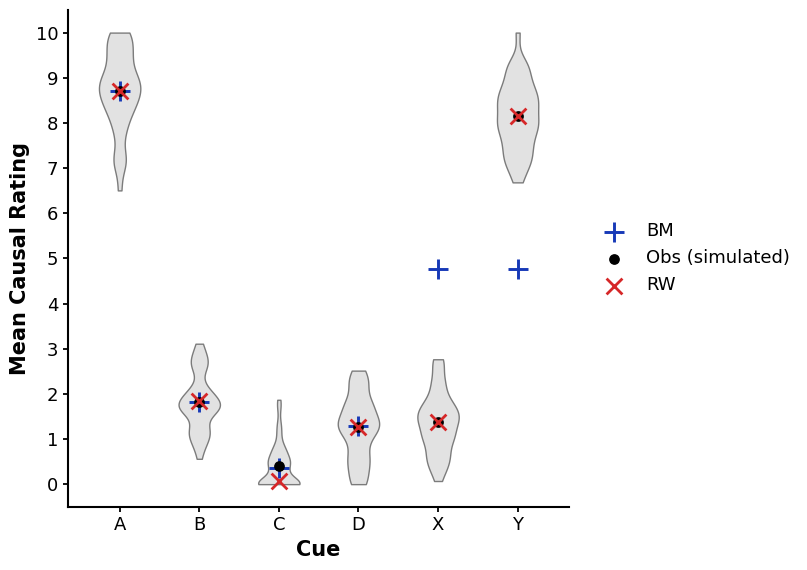

In [ ]:
cue_positions = np.arange(N_CUES)
fig, ax = plt.subplots(figsize=(8.2, 5.8))
violin_data = [synthetic_ratings[:, cue_index] for cue_index in range(N_CUES)]
violin_parts = ax.violinplot(
    violin_data,
    positions=cue_positions,
    widths=0.52,
    showmeans=False,
    showmedians=False,
    showextrema=False,
    bw_method=0.30
)
for body in violin_parts["bodies"]:
    body.set_facecolor("#D9D9D9")
    body.set_edgecolor("#555555")
    body.set_linewidth(1.0)
    body.set_alpha(0.75)

ax.scatter(cue_positions, bm_ratings, color="#1739B7", marker="+", s=190, linewidths=2.1, label="BM", zorder=4)
ax.scatter(cue_positions, synthetic_mean_ratings, color="black", marker="o", s=45, label="Obs (simulated)", zorder=5)
ax.scatter(cue_positions, rw_ratings, color="#D62728", marker="x", s=130, linewidths=2.0, label="RW", zorder=6)
ax.set_xticks(cue_positions)
ax.set_xticklabels(CUES, fontsize=14)
ax.set_xlabel("Cue", fontsize=15, fontweight="bold")
ax.set_ylabel("Mean Causal Rating", fontsize=15, fontweight="bold")
ax.set_xlim(-0.65, N_CUES - 0.35)
ax.set_ylim(-0.5, 10.5)
ax.set_yticks(np.arange(0, 11, 1))
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)
ax.tick_params(axis="both", labelsize=13, width=1.3)
ax.legend(frameon=False, fontsize=13, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()